# Retornos y Feature Engineering

In [4]:
import sys
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Transformación Base: Log Returns y Retornos Simples

### Contexto y Fundamento Técnico
Antes de construir cualquier factor cuantitativo, es fundamental transformar la serie de precios brutos ($Close$ / $Adj Close$) en su representación estacionaria: los retornos. Los precios de los activos presentan no-estacionariedad y tendencias estocásticas, lo que impide usarlos directamente en modelos estadísticos.

En este bloque transformamos la matriz de precios limpios en dos tipos de rendimientos primarios:
* **Log Returns (Retornos Logarítmicos):** Utilizados para el cálculo de volatilidad, aditividad temporal a lo largo del tiempo ($\ln(P_t) - \ln(P_{t-1})$) y modelado estadístico.
* **Simple Returns (Retornos Discretos):** Utilizados para reflejar el P&L real de las estrategias, agregación transversal (cross-sectional) de activos en el portafolio y cálculo de factores de iliquidez.

También se calulará el acumulativo:
* **Cumulative Returns (Retornos Acumulados)**: Utilizados para reconstruir la curva de patrimonio (Equity Curve), calcular la racha de pérdidas máxima (Maximum Drawdown) y comparar el rendimiento total de distintos activos normalizados desde un mismo punto de partida ($t=0$).

> **Propósito:** Esta capa no se considera un factor en sí misma, sino la materia prima matemática a partir de la cual se derivará toda la biblioteca de señales de inversión.

In [5]:
from src.features.returns import compute_simple_returns, compute_cumulative_returns, compute_log_returns
prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

In [6]:
simple_returns = compute_simple_returns(prices)
log_returns = compute_log_returns(prices)
cumulative_returns = compute_cumulative_returns(prices)

# Store each Data Frame in a separate parquet file in the processed data folder
simple_returns.to_parquet("../data/processed/simple_returns.parquet")
log_returns.to_parquet("../data/processed/log_returns.parquet")
cumulative_returns.to_parquet("../data/processed/cumulative_returns.parquet")

## 2. Factores de Momentum y Reversión

### Contexto y Fundamento Técnico
El efecto *Momentum* es una de las anomalías de mercado más documentadas en la literatura cuantitativa (Jegadeesh & Titman, 1993). Establece que los activos que han mostrado un rendimiento superior en el pasado reciente tienden a seguir superando al mercado en el corto/medio plazo, y viceversa.

Para capturar la estructura temporal de esta anomalía sin sesgar la señal, aislamos dos dinámicas complementarias pero conceptualmente opuestas:

* **12-1 Momentum (Momentum Intermedio):** Calcula el rendimiento acumulado desde el mes $t-12$ hasta el mes $t-1$. **¿Por qué excluimos el último mes ($t-1$)?** Para evitar la contaminación por el efecto de *microestructura de mercado* y la reversión a muy corto plazo.
* **1-Month Reversal (Reversión a Corto Plazo):** Mide exclusivamente el retorno del último mes ($t-1$). Captura el exceso de reacción (*overreaction*) de los inversores a corto plazo y los desequilibrios temporales de oferta/demanda.

> **Propósito:** Generar señales de tendencia robustas separando el impulso de medio plazo de la fricción/reversión de corto plazo.

In [7]:
from src.features.momentum import compute_12_1_momentum, compute_short_term_reversal

momentum_12_1 = compute_12_1_momentum(prices)
short_term_reversal = compute_short_term_reversal(prices)

Una vez tenemos construidos los dos factores relacionados con el momentum vamos a intentar validar cada uno de los factores. 

### 2.1 Validación del 12-1 Momentum (sanity check)

In [8]:
print("12-1 Momentum global statistics:")
print(momentum_12_1.stack().replace([np.inf, -np.inf], np.nan).describe())

12-1 Momentum global statistics:
count    1.644211e+06
mean     1.722303e-01
std      3.411661e-01
min     -9.799875e-01
25%     -1.483665e-02
50%      1.390082e-01
75%      3.066314e-01
max      1.150576e+01
dtype: float64


El análisis estadístico del factor 12-1 Momentum confirma la correcta construcción de la señal y su coherencia financiera. Por un lado, los valores límites respetan los bordes teóricos del mercado, donde el mínimo no sobrepasa el tope natural de pérdidas del $-100\%$ y los máximos capturan movimientos alcistas explosivos sin registrar valores corruptos o infinitos. 

Por otro lado, tanto la media como la mediana se posicionan en terreno positivo, reflejando fielmente el sesgo alcista de fondo de la renta variable. Finalmente, el indicador muestra una dispersión saludable entre activos, garantizando la variabilidad transversal necesaria para poder clasificar las acciones según su rendimiento en el modelo.

In [9]:
print("12-1 Momentum — NaN count by ticker:")
print(momentum_12_1.isna().sum())

12-1 Momentum — NaN count by ticker:
Ticker
A        252
AAPL     252
ABBV    1006
ABNB    3006
ABT      252
        ... 
XYZ     1733
YUM      252
ZBH      252
ZBRA     252
ZTS     1027
Length: 499, dtype: int64


Se observan varios ejemplos de empresas que cotizaron durante todo el intervalo temporal escogido y que por lo tanto, como el Momentum necesita de un año para poder calularse, tienen 252 valores NaN. 

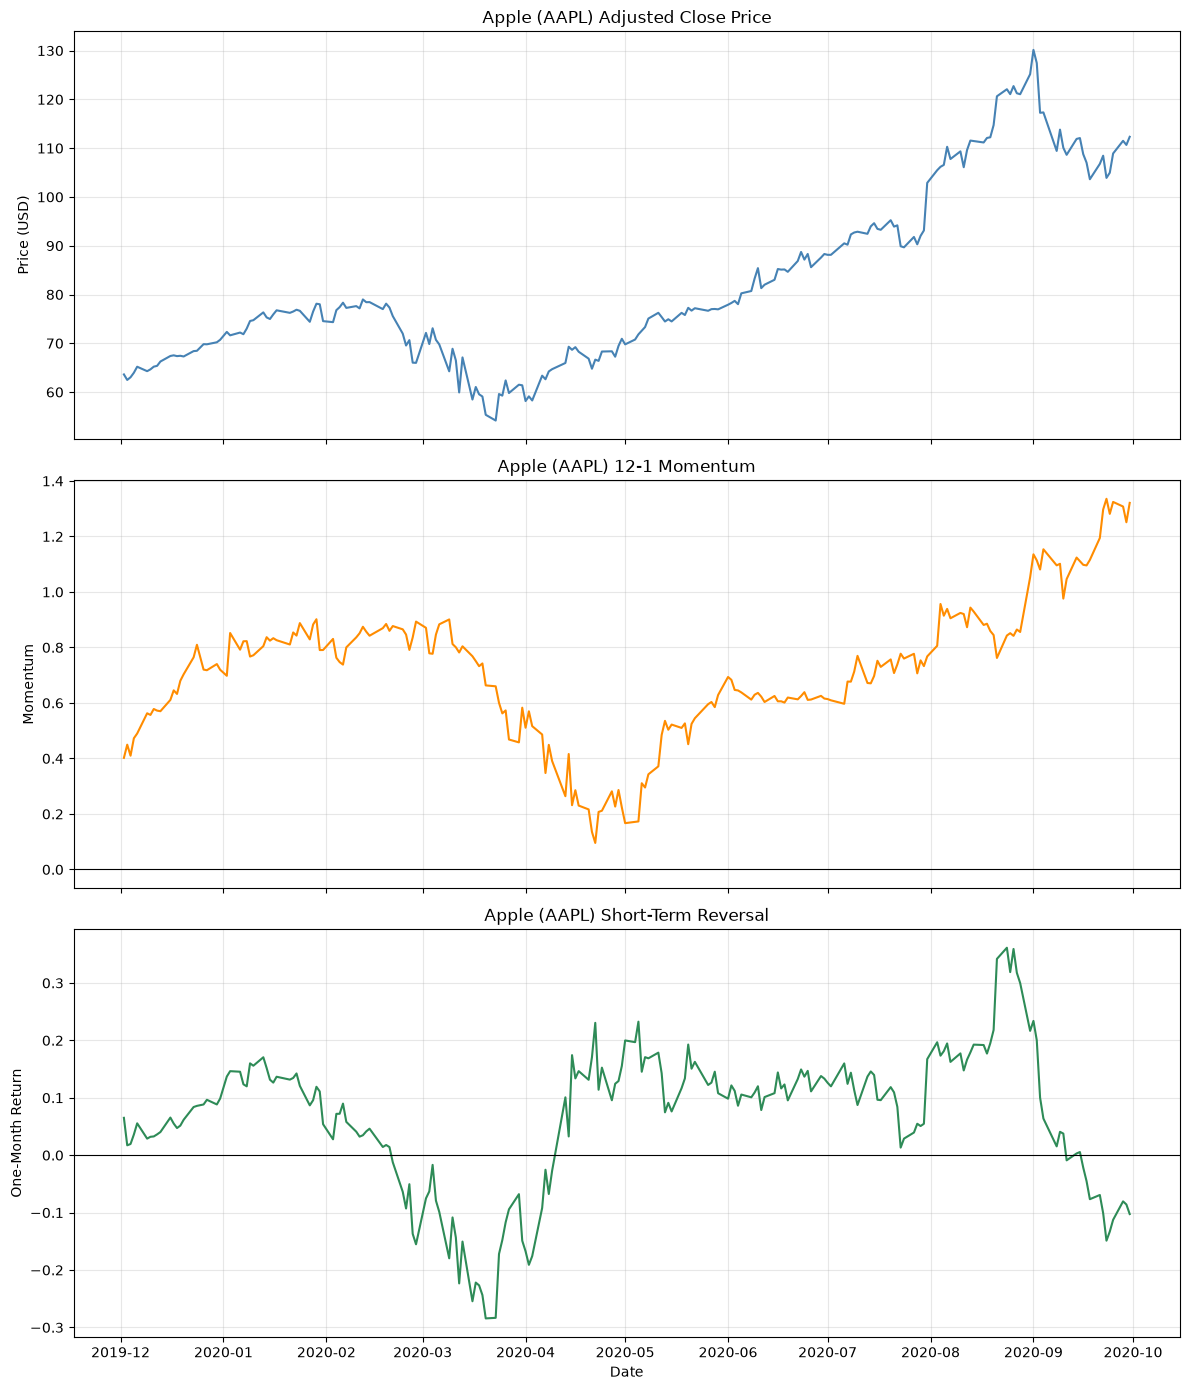

In [10]:
# Ensure that the date index has datetime format
prices.index = pd.to_datetime(prices.index)

# Calculate features using the complete price history
aapl_adj_close = prices["Adj Close"]["AAPL"]

momentum_12_1 = compute_12_1_momentum(prices)
aapl_momentum = momentum_12_1["AAPL"]

short_term_reversal = compute_short_term_reversal(prices)
aapl_reversal = short_term_reversal["AAPL"]

# Select the period to visualize
start_date = "2019-12-01"
end_date = "2020-09-30"

aapl_adj_close = aapl_adj_close.loc[start_date:end_date]
aapl_momentum = aapl_momentum.loc[start_date:end_date]
aapl_reversal = aapl_reversal.loc[start_date:end_date]

# Create three vertically stacked charts
fig, ax = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Chart 1: Adjusted Close price
ax[0].plot(aapl_adj_close.index, aapl_adj_close, color="steelblue")
ax[0].set_title("Apple (AAPL) Adjusted Close Price")
ax[0].set_ylabel("Price (USD)")
ax[0].grid(True, alpha=0.3)

# Chart 2: 12-1 momentum
ax[1].plot(aapl_momentum.index, aapl_momentum, color="darkorange")
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_title("Apple (AAPL) 12-1 Momentum")
ax[1].set_ylabel("Momentum")
ax[1].grid(True, alpha=0.3)

# Chart 3: Short-term reversal
ax[2].plot(aapl_reversal.index, aapl_reversal, color="seagreen")
ax[2].axhline(0, color="black", linewidth=0.8)
ax[2].set_title("Apple (AAPL) Short-Term Reversal")
ax[2].set_xlabel("Date")
ax[2].set_ylabel("One-Month Return")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Hemos decidido representar solamente la crisis del COVID 19 como ilustración de las características del Momentum (si graficábamos todo el intervalo temporal, se hacía muy difícil iddentificar esas caracteríticas). 

Para empezar, podemos observar el desfase del último mes (El "efecto 12-1") si nos vamos a la caída que tuvimos entre marzo y abril del año 2020. Se oberva claramente que el indicador de Momentum no reacciona inmediatamente a ese movimiento reciente, precisamente porque al haber excluido el mes $t-1$ ($21$ días), la curva del Momentum tarda cerca de un mes en "enterarse" de esa bajada abrrupta. En la subida posterior se ve exactamente el mismo fenómeno. 

Relacionado con esto, si nos fijamos en la recuperación que se dio a partir del punto más bajo a finales de marzo de 2020, vemos que el Momentum alcanza el mínimo cuando la tendencia bajista se consolida y empieza a subir recuperando máximos cuando la subida previa ha sido mas o menos constante durante meses. 

Por último, si nos fijamos en los datos del Data Frame de Momentum, vemos que para empresas que empezaron a cotizar el 1 de enero de 2010 el Momentum es NaN hasta 252 días despues, precisamente porwue antes no había datos para calcularlo. 

### 2.2 Validación de la reversión a corto plazo (sanity check)

In [11]:
print("\nShort-Term Reversal global statistics:")
print(short_term_reversal.stack().replace([np.inf, -np.inf], np.nan).describe())


Short-Term Reversal global statistics:
count    1.759361e+06
mean     1.527410e-02
std      8.726311e-02
min     -8.716766e-01
25%     -3.088289e-02
50%      1.508761e-02
75%      5.949096e-02
max      2.184570e+00
dtype: float64


El análisis estadístico del factor 1-Month Reversal valida la correcta implementación de la señal y su coherencia con la dinámica de corto plazo. Sus valores límites respetan los bordes lógicos del mercado, con un mínimo del $-87,17\%$ que se sitúa dentro del tope teórico de pérdidas y un máximo del $+218,46\%$ que captura rebotes mensuales intensos sin mostrar datos corruptos o infinitos. 

A diferencia del momentum de medio plazo, su media del $+1,53\%$ y su mediana del $+1,51\%$ se ubican muy cercanas a cero, lo que confirma su naturaleza oscilatoria e hiperactiva centrada en el equilibrio del mercado. 

Finalmente, la desviación típica del $8,73\%$ evidencia una dispersión acotada pero suficiente, garantizando la sensibilidad transversal necesaria para detectar reacciones exageradas del precio en ventanas de 21 días.

In [12]:
print("\nShort-Term Reversal — NaN count by ticker:")
print(short_term_reversal.isna().sum())


Short-Term Reversal — NaN count by ticker:
Ticker
A         21
AAPL      21
ABBV     775
ABNB    2775
ABT       21
        ... 
XYZ     1502
YUM       21
ZBH       21
ZBRA      21
ZTS      796
Length: 499, dtype: int64


En este caso, como el short term Reversal necesita de 21 días para calularse, las empresas que comenzaron a cotizar desde el 1 de enero de 2010 presentan 21 valores NaN. 

Si nos fijamos ahora en la tercera gráfica de arriba obervamos una coincidencia de las caídas y subidas entre el precio y el factor 1-Month Reversal, pero de forma mucho más abrupta en este último. Esto se debe a que el indicador mide la variación porcentual del activo en un horizonte estrecho de solo 21 días de negociación. Al no aplicar ningún tipo de filtro o desfase temporal, la señal reacciona sin amortiguación a la volatilidad de corto plazo, transformando los giros del mercado en picos y valles extremadamente pronunciados que pueden volverse negativos en cuestión de días ante cualquier corrección puntual. 

Asimismo, el hecho de que el factor oscile en lateral alrededor de cero durante etapas de subida pautada y constante del precio refleja que una tendencia alcista prolongada no implica aceleraciones continuas semana a semana; si el activo sube a un ritmo homogéneo mes a mes, su rendimiento a 21 días se mantiene estable en una franja estrecha, capturando exclusivamente el impulso reciente y no la tendencia acumulada de fondo.

In [13]:
# Store each Data Frame in a separate parquet file in the processed data folder
momentum_12_1.to_parquet("../data/processed/momentum_12_1.parquet")
short_term_reversal.to_parquet("../data/processed/short_term_reversal.parquet")

## 3. Factores de Riesgo, Volatilidad Asimétrica y Anomalía Low-Vol

### Contexto y Fundamento Técnico (Justificación de la Selección de Factores de Volatilidad)

En la construcción del conjunto de *features* cuantitativas del modelo, se justifica la implementación de cuatro métricas de volatilidad (**Volatilidad Total**, **Low-Volatility Factor**, **Downside Volatility** y **Upside Volatility**) evaluadas en dos ventanas temporales distintas (**21 días** y **252 días**).

La inclusión de estas cuatro señales responde a la necesidad de capturar tanto la magnitud del riesgo de un activo como su **asimetría estructural**:

* **Volatilidad Total (Rolling Volatility):** Mide la desviación estándar de los retornos diarios dentro de una ventana móvil. Sirve como métrica base de agitación del mercado sin discriminar la dirección del precio.
* **Low-Volatility Factor (Factor de Baja Volatilidad):** Se calcula como el negativo de la volatilidad móvil ($-1 \times \text{Volatilidad}$). Su implementación es clave para capturar la **Anomalía de Baja Volatilidad** (*Low-Volatility Anomaly*), fenómeno que contradice la teoría clásica del CAPM (*Capital Asset Pricing Model*) e invalida la premisa tradicional de que una mayor rentabilidad exige inevitablemente un mayor riesgo.
  * *Fundamento conductual e institucional:* Esta anomalía se explica por el **Efecto Lotería** (inversores minoristas sobrepagando por acciones ultravolátiles buscando ganancias explosivas), el **Sesgo de Exceso de Confianza** y la **Restricción de Apalancamiento** que sufren los fondos institucionales (forzados a comprar acciones de alta volatilidad/beta para intentar batir a su índice al no poder apalancarse). Transforma la señal para que el modelo favorezca activos estables que históricamente ofrecen mejores retornos ajustados por riesgo.
* **Downside Volatility (Volatilidad Bajista):** Aísla y mide la desviación estándar considerando **únicamente los días con rendimientos negativos**. Financieramente responde a la gestión del riesgo asimétrico y al *Leverage Effect* (las caídas aumentan el apalancamiento financiero de la empresa, desatando espirales de volatilidad hacia abajo). Captura el pánico colectivo, la necesidad urgente de liquidez y la ejecución automática de órdenes de *stop-loss*, siendo la base cuantitativa de métricas como el Ratio de Sortino.
* **Upside Volatility (Volatilidad Alcista):** Mide la desviación estándar de los **días con rendimientos positivos**. Representa la variabilidad provocada por impulsos alcistas y la acumulación gradual de optimismo, permitiendo al modelo discriminar si la volatilidad total proviene de un deterioro de mercado (riesgo real) o de un comportamiento explosivo al alza (volatilidad deseable).

In [14]:
from src.features.volatility import compute_rolling_volatility, compute_downside_volatility
from src.features.volatility import compute_upside_volatility, compute_low_volatility_factor


rolling_volatility = compute_rolling_volatility(log_returns, window=252)
downside_volatility = compute_downside_volatility(log_returns, window=252)
upside_volatility = compute_upside_volatility(log_returns, window=252)
low_volatility = compute_low_volatility_factor(log_returns, window=252)

### 3.1 Validación de las volatilidades 

In [19]:
# Upside Volatility
print("Upside Volatility — NaN count by ticker:")
print(upside_volatility.isna().sum())

print("\nUpside Volatility — global statistics:")
print(
    upside_volatility
    .stack()
    .replace([np.inf, -np.inf], np.nan)
    .describe()
)

Upside Volatility — NaN count by ticker:
Ticker
A         39
AAPL      40
ABBV     794
ABNB    2796
ABT       33
        ... 
XYZ     1522
YUM       41
ZBH       47
ZBRA      39
ZTS      819
Length: 499, dtype: int64

Upside Volatility — global statistics:
count    1.747377e+06
mean     1.233461e-02
std      6.090967e-03
min      2.315572e-03
25%      8.226682e-03
50%      1.074885e-02
75%      1.473846e-02
max      9.280487e-02
dtype: float64


El análisis estadístico de la Upside Volatility, evaluada fijando el periodo mínimo de calentamiento en 21 días, consolida el diagnóstico de asimetría de mercado observada al compararla con la Downside Volatility. La variable registra una media del 1,23% y una mediana del 1,07%, manteniéndose de forma consistente por debajo de las métricas bajistas. Esto confirma que las fases de subida en los precios se desarrollan con menor agitación y de manera más gradual. 

La serie muestra un comportamiento impecable y homogéneo, situando su mínimo en el 0,23% y su máximo en un 9,28% durante impulsos alcistas puntuales, mientras que el rango intercuartílico entre el 0,82% y el 1,47% refleja una variable limpia, continua y lista para integrarse en el modelo.

In [15]:
# Downside Volatility
print("Downside Volatility — NaN count by ticker:")
print(downside_volatility.isna().sum())

print("\nDownside Volatility — global statistics:")
print(
    downside_volatility
    .stack()
    .replace([np.inf, -np.inf], np.nan)
    .describe()
)

Downside Volatility — NaN count by ticker:
Ticker
A         46
AAPL      50
ABBV     798
ABNB    2794
ABT       56
        ... 
XYZ     1523
YUM       49
ZBH       40
ZBRA      49
ZTS      815
Length: 499, dtype: int64

Downside Volatility — global statistics:
count    1.745649e+06
mean     1.325634e-02
std      6.851448e-03
min      2.320790e-03
25%      8.871991e-03
50%      1.147549e-02
75%      1.550001e-02
max      9.548943e-02
dtype: float64


El análisis estadístico de la Downside Volatility, evaluada con un periodo mínimo de calentamiento de 21 días, confirma la asimetría del riesgo en el universo de activos analizado. En primer lugar, destaca su asimetría respecto a la Upside Volatility, al presentar una media del 1,32% y una mediana del 1,15%, ambas superiores a sus equivalentes alcistas (1,23% y 1,07% respectivamente).

Esto valida empíricamente que las jornadas de pérdidas registran una dispersión y violencia sensiblemente mayor que las de ganancias, un fenómeno alineado con el conocido Leverage Effect. En cuanto al comportamiento de la serie, registra un mínimo del 0,23% y un máximo del 9,54% en episodios de liquidación severa, mientras que la estrecha dispersión entre su primer y tercer cuartil (0,88% - 1,55%) confirma una variable estable, continua y libre de distorsiones extremas.

In [17]:
# Low-Volatility Factor
print("Low-Volatility Factor — NaN count by ticker:")
print(low_volatility.isna().sum())

print("\nLow-Volatility Factor — global statistics:")
print(
    low_volatility
    .stack()
    .replace([np.inf, -np.inf], np.nan)
    .describe()
)

Low-Volatility Factor — NaN count by ticker:
Ticker
A        252
AAPL     252
ABBV    1006
ABNB    3006
ABT      252
        ... 
XYZ     1733
YUM      252
ZBH      252
ZBRA     252
ZTS     1027
Length: 499, dtype: int64

Low-Volatility Factor — global statistics:
count    1.644211e+06
mean    -1.828466e-02
std      8.024948e-03
min     -1.137564e-01
25%     -2.154298e-02
50%     -1.627982e-02
75%     -1.283204e-02
max     -3.277126e-03
dtype: float64


Observamos, al igual que el la rolling volatility, que el low-volatility factor tiene muchos valores que comienzan 252 días depsués de empezar a cotizar sus respectivas empresas, lo que sigiere que la volatilidad está bien calulada. 

Por otro lado, si nos fijamos en las global statistics vemos que al haber definido el factor como -rolling_volatility, el hecho de que todos los valores sean menores que cero confirma que no hay errores de signo ni volatilidades negativas en el origen. Por otro lado vemos que el máximo corresponde a una acción ultraestable (volatilidad diaria del $0,33\%$) y el minimo a una super slvaje (volatilidad diaria del $11,38\%$) dando una media anualizada de aproximadamente un 29%, lo cual es bastante razonable. 

Obviamente no hemos metido la rolliing volatility básicamente porque es una imagen especular de la low volatility (debido a como se calula) 

In [ ]:
# Store each Data Frame in a separate parquet file in the processed data folder
rolling_volatility.to_parquet("../data/processed/rolling_volatility.parquet")
downside_volatility.to_parquet("../data/processed/downside_volatility.parquet")
upside_volatility.to_parquet("../data/processed/upside_volatility.parquet")

## 4. Factores de Liquidez (Medida de Amihud)

### Contexto y Fundamento Técnico
La liquidez es una dimensión de riesgo sistemático crucial: las acciones ilíquidas suelen requerir una prima de rentabilidad exigida por el mercado. Dado que operamos exclusivamente con datos de volumen y precio (OHLCV) sin necesidad de datos de nivel 2 (order book), la métrica académica estándar de referencia es el **Índice de Iliquidez de Amihud (2002)**.

$$K_t = \frac{|R_t|}{Dollar Volume_t}$$

* **Interpretación:** Mide el impacto absoluto en el precio ($|R_t|$) generado por cada dólar negociado en el mercado. 
* **Aplicación:** Valores altos indican activos con libros de órdenes "finos" o poco profundos, donde una orden media puede desplazar drásticamente el precio.

> **Propósito:** Detectar la fricción del mercado para evitar sobreponderar acciones difíciles de ejecutar en la vida real o para explotar la prima de iliquidez en el portafolio.